# 1. PageRank Algorithm



## 2. Import Required Libraries

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## 3. Create a Directed Graph

Consider four web pages A, B, C and D with the following links:

- A to B, C
- B to C, D
- C to A
- D to C


In [2]:
G = nx.DiGraph()

edges = [
    ('A', 'B'), ('A', 'C'),
    ('B', 'C'), ('B', 'D'),
    ('C', 'A'),
    ('D', 'C')
]

G.add_edges_from(edges)

print('Nodes:', list(G.nodes()))
print('Edges:', list(G.edges()))

Nodes: ['A', 'B', 'C', 'D']
Edges: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'), ('C', 'A'), ('D', 'C')]


## 4. Visualize the Graph

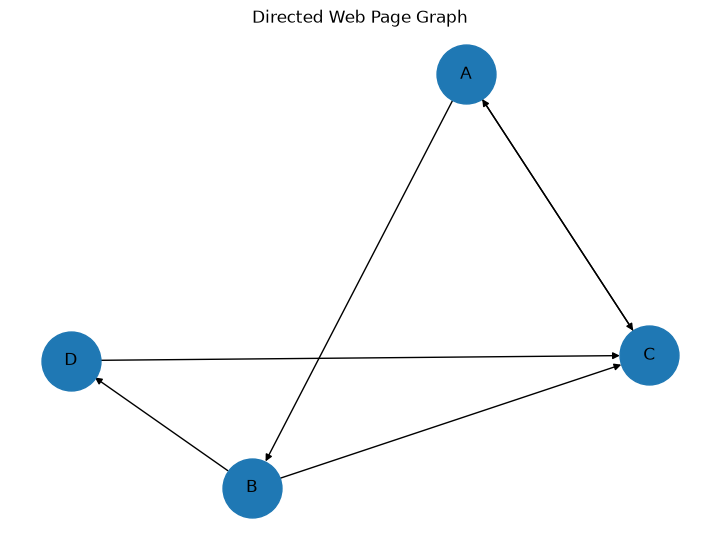

In [3]:
plt.figure(figsize=(7, 5))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=1800, arrows=True,
        font_size=12)
plt.title('Directed Web Page Graph')
plt.show()

## 5. Implement PageRank from Scratch

We start with equal PageRank for every page. In every iteration, each page distributes its current rank equally among its outgoing links.

The damping factor is set to 0.85.

In [4]:
def page_rank(graph, damping=0.85, max_iter=100, tol=1e-6):
    nodes = list(graph.nodes())
    n = len(nodes)
    rank = {node: 1 / n for node in nodes}

    for iteration in range(1, max_iter + 1):
        new_rank = {node: (1 - damping) / n for node in nodes}

        # Handle dangling nodes by distributing their rank to all nodes
        dangling_rank = sum(
            rank[node] for node in nodes if graph.out_degree(node) == 0
        )

        for node in nodes:
            new_rank[node] += damping * dangling_rank / n

        for node in nodes:
            out_degree = graph.out_degree(node)

            if out_degree > 0:
                contribution = damping * rank[node] / out_degree

                for neighbour in graph.successors(node):
                    new_rank[neighbour] += contribution

        # Check convergence
        difference = sum(abs(new_rank[node] - rank[node]) for node in nodes)
        rank = new_rank

        print(f'Iteration {iteration}:',
              {node: round(rank[node], 6) for node in nodes})

        if difference < tol:
            print(f'Converged after {iteration} iterations.')
            break

    return rank

## 6. Calculate PageRank

In [5]:
pr = page_rank(G)

print('\nFinal PageRank:')
for node, score in sorted(pr.items(), key=lambda x: x[1], reverse=True):
    print(f'{node}: {score:.6f}')

Iteration 1: {'A': 0.25, 'B': 0.14375, 'C': 0.4625, 'D': 0.14375}
Iteration 2: {'A': 0.430625, 'B': 0.14375, 'C': 0.327031, 'D': 0.098594}
Iteration 3: {'A': 0.315477, 'B': 0.220516, 'C': 0.365414, 'D': 0.098594}
Iteration 4: {'A': 0.348102, 'B': 0.171578, 'C': 0.349101, 'D': 0.131219}
Iteration 5: {'A': 0.334236, 'B': 0.185443, 'C': 0.3699, 'D': 0.11042}
Iteration 6: {'A': 0.351915, 'B': 0.17955, 'C': 0.352221, 'D': 0.116313}
Iteration 7: {'A': 0.336888, 'B': 0.187064, 'C': 0.362239, 'D': 0.113809}
Iteration 8: {'A': 0.345403, 'B': 0.180677, 'C': 0.356917, 'D': 0.117002}
Iteration 9: {'A': 0.34088, 'B': 0.184296, 'C': 0.360536, 'D': 0.114288}
Iteration 10: {'A': 0.343956, 'B': 0.182374, 'C': 0.357844, 'D': 0.115826}
Iteration 11: {'A': 0.341668, 'B': 0.183681, 'C': 0.359642, 'D': 0.115009}
Iteration 12: {'A': 0.343196, 'B': 0.182709, 'C': 0.358531, 'D': 0.115565}
Iteration 13: {'A': 0.342251, 'B': 0.183358, 'C': 0.359239, 'D': 0.115151}
Iteration 14: {'A': 0.342853, 'B': 0.182957, 'C'

## 7. Rank the Pages

The pages can now be ordered according to their PageRank values.

In [6]:
ranking = sorted(pr.items(), key=lambda x: x[1], reverse=True)

print('Page Ranking:')
for position, (node, score) in enumerate(ranking, start=1):
    print(f'{position}. Page {node} -> {score:.6f}')


Page Ranking:
1. Page C -> 0.358956
2. Page A -> 0.342612
3. Page B -> 0.183110
4. Page D -> 0.115322


## 8. Visualize the PageRank Scores

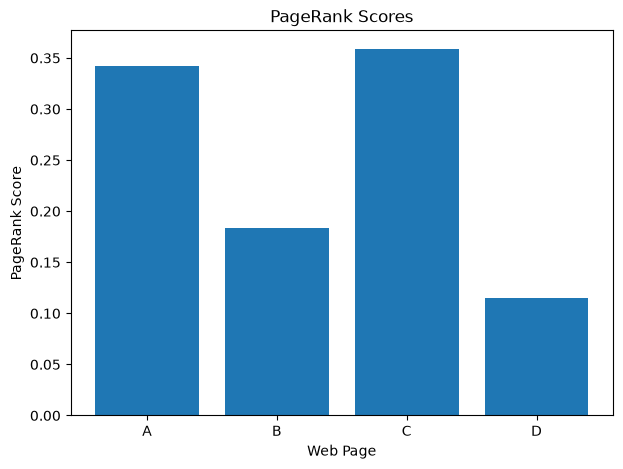

In [7]:
nodes = list(pr.keys())
scores = list(pr.values())

plt.figure(figsize=(7, 5))
plt.bar(nodes, scores)
plt.xlabel('Web Page')
plt.ylabel('PageRank Score')
plt.title('PageRank Scores')
plt.show()

## 9. Verify Using NetworkX

NetworkX provides a built-in PageRank implementation. We can compare it with our implementation.

In [8]:
nx_pr = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1e-6)

print('NetworkX PageRank:')
for node, score in sorted(nx_pr.items(), key=lambda x: x[1], reverse=True):
    print(f'{node}: {score:.6f}')

NetworkX PageRank:
C: 0.358956
A: 0.342612
B: 0.183111
D: 0.115322


## 10. Compare Both Results

In [9]:
print(f"{'Page':<8}{'From Scratch':<18}{'NetworkX':<18}{'Difference'}")
print('-' * 60)

for node in nodes:
    difference = abs(pr[node] - nx_pr[node])
    print(f"{node:<8}{pr[node]:<18.6f}{nx_pr[node]:<18.6f}{difference:.10f}")

Page    From Scratch      NetworkX          Difference
------------------------------------------------------------
A       0.342612          0.342612          0.0000005677
B       0.183110          0.183111          0.0000003676
C       0.358956          0.358956          0.0000004382
D       0.115322          0.115322          0.0000002381
